# 🚗 Driver Behavior Analysis & Clustering
This notebook performs automated data cleaning and applies clustering techniques to telematics data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# --- Visualization Configuration ---
plt.style.use('ggplot')
sns.set_palette('husl')
%matplotlib inline

## 1. Data Cleaning
The raw data is currently in a 'collapsed' format. We parse and cast the columns.

In [2]:
df_raw = pd.read_csv('driver-data.csv')
header = df_raw.columns[0].split(',')
df = df_raw[df_raw.columns[0]].str.split(',', expand=True)
df.columns = header

for col in df.columns:
    df[col] = pd.to_numeric(df[col])
df.head()

## 2. Exploratory Visualization
Understanding the spread of distance and speeding among drivers.

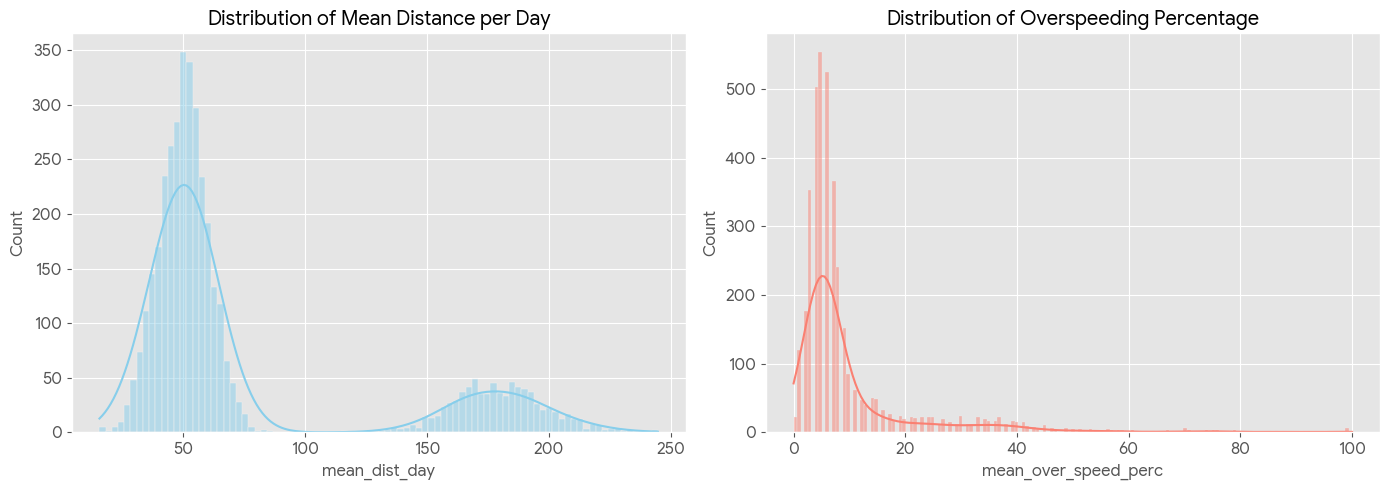

In [3]:
# Configuring a dual histogram layout
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['mean_dist_day'], kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Mean Distance per Day Distribution')

sns.histplot(df['mean_over_speed_perc'], kde=True, ax=ax[1], color='salmon')
ax[1].set_title('Overspeeding Percentage Distribution')

plt.tight_layout()
plt.show()

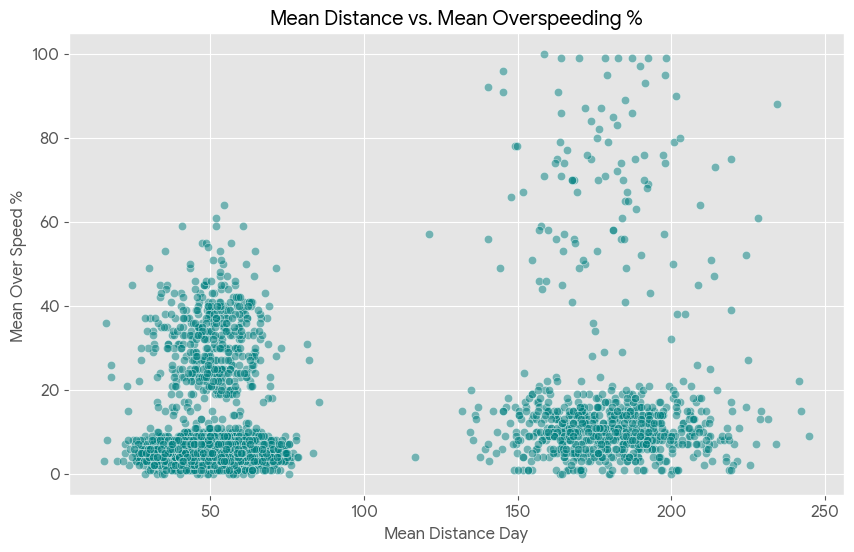

In [4]:
# Configuring the scatter plot to identify visual groups
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='mean_dist_day', y='mean_over_speed_perc', alpha=0.5, color='teal')
plt.title('Relationship: Distance vs. Speeding')
plt.show()

## 3. Driver Segmentation (Machine Learning)
Applying K-Means to officially group the drivers.

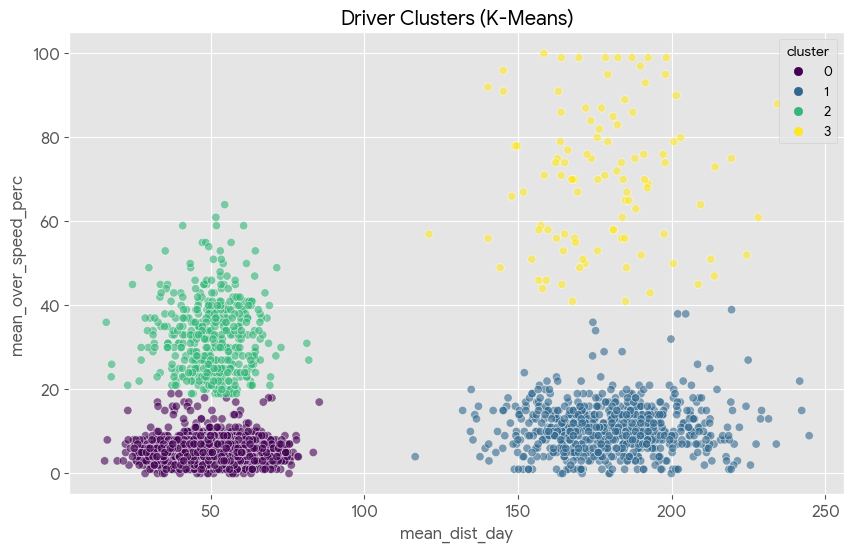

In [5]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(df[['mean_dist_day', 'mean_over_speed_perc']])

# Configuring the cluster visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='mean_dist_day', y='mean_over_speed_perc', hue='cluster', palette='viridis', alpha=0.6)
plt.title('Driver Risk Profiles (K-Means Clusters)')
plt.show()